<center>
    <h1><font color="blue">Data Preprocessing & Feature Engineering</font></h1>
    <h2>Student Exam Performance Dataset</h2>
</center>

## <font color="red">1. Import Libraries and Load Data</font>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [2]:
# Load the dataset
df = pd.read_csv('../dataset/student_exam_performance_dataset.csv')
print(f"Original dataset shape: {df.shape}")
df.head()

Original dataset shape: (10000, 23)


,student_id,gender,age,parental_education,family_income,internet_access,study_environment,study_hours_per_day,attendance_rate,sleep_hours,social_media_hours,assignment_completion_rate,participation_score,online_courses_completed,tutoring,math_score,reading_score,writing_score,science_score,final_exam_score,previous_gpa,pass_fail,grade_category
0,S00001,Male,17,High School,Medium,Yes,Quiet,2.98,96.5,6.05,0.1,80.5,68.7,1,Yes,42.8,62.4,54.8,51.8,49.1,2.44,Fail,F
1,S00002,Female,18,High School,Low,Yes,Quiet,4.45,95.7,6.96,2.9,70.9,92.6,0,Yes,77.9,73.5,64.4,61.6,70.1,2.79,Pass,C
2,S00003,Male,17,High School,Medium,No,Quiet,3.75,76.0,7.02,2.4,77.6,45.8,4,Yes,53.5,38.3,36.3,47.1,42.2,1.49,Fail,F
3,S00004,Male,18,Bachelor,Medium,Yes,Quiet,2.03,72.6,6.23,3.5,63.5,72.9,4,No,28.3,23.5,32.0,39.0,31.9,1.34,Fail,F
4,S00005,Male,18,Bachelor,Medium,Yes,Quiet,5.14,87.3,8.54,2.1,71.8,55.7,0,No,74.7,54.9,73.6,55.5,66.4,2.60,Pass,C


## <font color="red">2. Data Preprocessing</font>

### <font color="blue">2.1 Check Data Quality</font>

In [3]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum().sum())

# Check for duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Check data types
print("\nData Types:")
print(df.dtypes)

Missing Values:
0

Duplicate rows: 0

Data Types:
student_id                     object
gender                         object
age                             int64
parental_education             object
family_income                  object
internet_access                object
study_environment              object
study_hours_per_day           float64
attendance_rate               float64
sleep_hours                   float64
social_media_hours            float64
assignment_completion_rate    float64
participation_score           float64
online_courses_completed        int64
tutoring                       object
math_score                    float64
reading_score                 float64
writing_score                 float64
science_score                 float64
final_exam_score              float64
previous_gpa                  float64
pass_fail                      object
grade_category                 object
dtype: object


### <font color="blue">2.2 Handle Outliers</font>

From EDA, we identified outliers in several features. We'll use the IQR method to cap outliers.

In [4]:
# Function to cap outliers using IQR method
def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Cap outliers
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    return df

# Columns with outliers to handle
outlier_cols = ['study_hours_per_day', 'attendance_rate', 'sleep_hours', 'social_media_hours',
                'assignment_completion_rate', 'participation_score', 'final_exam_score', 'previous_gpa']

# Create a copy for preprocessing
df_processed = df.copy()

# Cap outliers
print("Outliers capped using IQR method:")
for col in outlier_cols:
    before_outliers = ((df_processed[col] < df_processed[col].quantile(0.25) - 1.5 * (df_processed[col].quantile(0.75) - df_processed[col].quantile(0.25))) | 
                       (df_processed[col] > df_processed[col].quantile(0.75) + 1.5 * (df_processed[col].quantile(0.75) - df_processed[col].quantile(0.25)))).sum()
    df_processed = cap_outliers(df_processed, col)
    print(f"  {col}: {before_outliers} outliers capped")

Outliers capped using IQR method:
  study_hours_per_day: 27 outliers capped
  attendance_rate: 36 outliers capped
  sleep_hours: 63 outliers capped
  social_media_hours: 36 outliers capped
  assignment_completion_rate: 30 outliers capped
  participation_score: 35 outliers capped
  final_exam_score: 95 outliers capped
  previous_gpa: 62 outliers capped


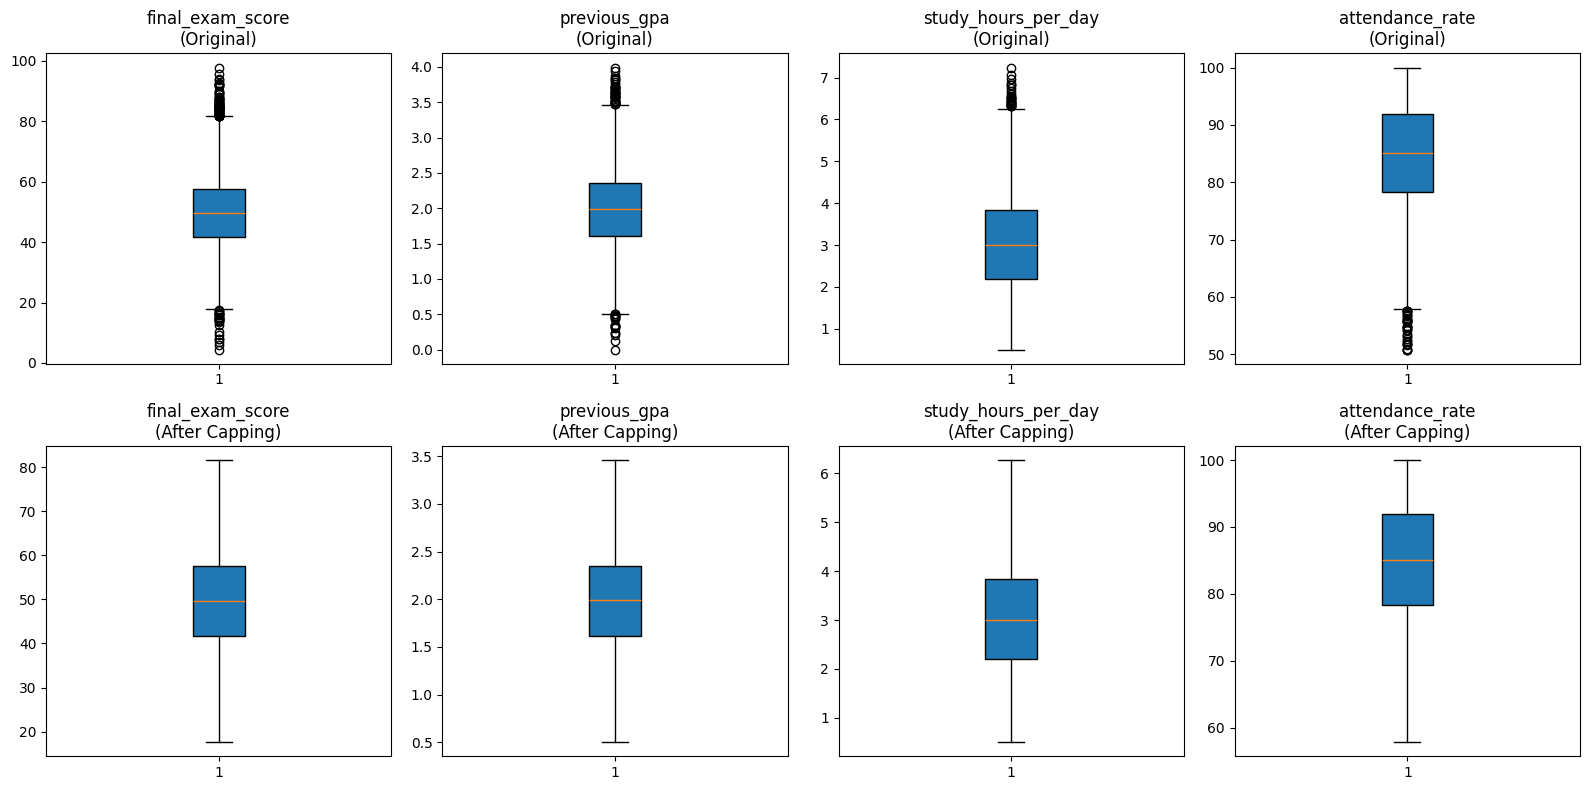

In [5]:
# Visualize before and after outlier handling
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(['final_exam_score', 'previous_gpa', 'study_hours_per_day', 'attendance_rate']):
    # Before
    axes[i].boxplot(df[col], patch_artist=True)
    axes[i].set_title(f'{col}\n(Original)')
    
    # After
    axes[i+4].boxplot(df_processed[col], patch_artist=True)
    axes[i+4].set_title(f'{col}\n(After Capping)')

plt.tight_layout()
plt.savefig('../docs/outlier_handling_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### <font color="blue">2.3 Encode Categorical Variables</font>

In [6]:
# Identify categorical columns
categorical_cols = df_processed.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {categorical_cols}")

# Separate by encoding type
# Binary columns -> Label Encoding
# Nominal columns -> One-Hot Encoding
# Ordinal columns -> Ordinal Encoding (manual mapping)

binary_cols = ['gender', 'internet_access', 'tutoring', 'pass_fail']
nominal_cols = ['study_environment']
ordinal_cols = ['parental_education', 'family_income', 'grade_category']

print(f"\nBinary columns (Label Encoding): {binary_cols}")
print(f"Nominal columns (One-Hot): {nominal_cols}")
print(f"Ordinal columns (Ordinal Encoding): {ordinal_cols}")

Categorical columns: ['student_id', 'gender', 'parental_education', 'family_income', 'internet_access', 'study_environment', 'tutoring', 'pass_fail', 'grade_category']

Binary columns (Label Encoding): ['gender', 'internet_access', 'tutoring', 'pass_fail']
Nominal columns (One-Hot): ['study_environment']
Ordinal columns (Ordinal Encoding): ['parental_education', 'family_income', 'grade_category']


In [7]:
# 1. Label Encoding for binary columns
label_encoders = {}

for col in binary_cols:
    le = LabelEncoder()
    df_processed[col + '_encoded'] = le.fit_transform(df_processed[col])
    label_encoders[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

gender: {'Female': np.int64(0), 'Male': np.int64(1)}
internet_access: {'No': np.int64(0), 'Yes': np.int64(1)}
tutoring: {'No': np.int64(0), 'Yes': np.int64(1)}
pass_fail: {'Fail': np.int64(0), 'Pass': np.int64(1)}


In [8]:
# 2. Ordinal Encoding for ordinal columns
# Parental Education
education_order = {'High School': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3}
df_processed['parental_education_encoded'] = df_processed['parental_education'].map(education_order)
print(f"parental_education: {education_order}")

# Family Income
income_order = {'Low': 0, 'Medium': 1, 'High': 2}
df_processed['family_income_encoded'] = df_processed['family_income'].map(income_order)
print(f"family_income: {income_order}")

# Grade Category
grade_order = {'F': 0, 'D': 1, 'C': 2, 'B': 3, 'A': 4}
df_processed['grade_category_encoded'] = df_processed['grade_category'].map(grade_order)
print(f"grade_category: {grade_order}")

parental_education: {'High School': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3}
family_income: {'Low': 0, 'Medium': 1, 'High': 2}
grade_category: {'F': 0, 'D': 1, 'C': 2, 'B': 3, 'A': 4}


In [9]:
# 3. One-Hot Encoding for nominal columns
df_processed = pd.get_dummies(df_processed, columns=nominal_cols, prefix=nominal_cols, dtype=int)

print("One-Hot Encoded columns created:")
for col in nominal_cols:
    new_cols = [c for c in df_processed.columns if c.startswith(col)]
    print(f"  {col}: {new_cols}")

One-Hot Encoded columns created:
  study_environment: ['study_environment_Moderate', 'study_environment_Noisy', 'study_environment_Quiet']


In [10]:
# Display encoded columns
encoded_cols = [c for c in df_processed.columns if '_encoded' in c or any(c.startswith(col + '_') for col in nominal_cols)]
print(f"\nTotal encoded columns: {len(encoded_cols)}")
df_processed[encoded_cols].head()


Total encoded columns: 10


,gender_encoded,internet_access_encoded,tutoring_encoded,pass_fail_encoded,parental_education_encoded,family_income_encoded,grade_category_encoded,study_environment_Moderate,study_environment_Noisy,study_environment_Quiet
0,1,1,1,0,0,1,0,0,0,1
1,0,1,1,1,0,0,2,0,0,1
2,1,0,1,0,0,1,0,0,0,1
3,1,1,0,0,1,1,0,0,0,1
4,1,1,0,1,1,1,2,0,0,1


## <font color="red">3. Feature Engineering</font>

### <font color="blue">3.1 Create New Features</font>

Based on EDA insights, we'll create the following new features:

In [11]:
# 1. Average Subject Score
df_processed['avg_subject_score'] = (df_processed['math_score'] + 
                                      df_processed['reading_score'] + 
                                      df_processed['writing_score'] + 
                                      df_processed['science_score']) / 4

print("Feature 1: avg_subject_score - Average of all subject scores")
print(f"  Correlation with final_exam_score: {df_processed['avg_subject_score'].corr(df_processed['final_exam_score']):.4f}")

Feature 1: avg_subject_score - Average of all subject scores
  Correlation with final_exam_score: 0.9852


In [12]:
# 2. Study Efficiency Ratio (study hours / social media hours)
# Add small value to avoid division by zero
df_processed['study_efficiency'] = df_processed['study_hours_per_day'] / (df_processed['social_media_hours'] + 0.1)

print("Feature 2: study_efficiency - Ratio of study hours to social media hours")
print(f"  Correlation with final_exam_score: {df_processed['study_efficiency'].corr(df_processed['final_exam_score']):.4f}")

Feature 2: study_efficiency - Ratio of study hours to social media hours
  Correlation with final_exam_score: 0.2240


In [13]:
# 3. Engagement Score (combined metric)
# Normalize each component first, then combine
attendance_norm = df_processed['attendance_rate'] / 100
assignment_norm = df_processed['assignment_completion_rate'] / 100
participation_norm = df_processed['participation_score'] / 100

df_processed['engagement_score'] = (attendance_norm + assignment_norm + participation_norm) / 3 * 100

print("Feature 3: engagement_score - Combined attendance, assignment, participation")
print(f"  Correlation with final_exam_score: {df_processed['engagement_score'].corr(df_processed['final_exam_score']):.4f}")

Feature 3: engagement_score - Combined attendance, assignment, participation
  Correlation with final_exam_score: 0.2534


In [14]:
# 4. Academic Risk Flag (binary)
# Students with low previous_gpa (< 2.0) and low study hours (< 2)
df_processed['academic_risk'] = ((df_processed['previous_gpa'] < 2.0) & 
                                  (df_processed['study_hours_per_day'] < 2)).astype(int)

print("Feature 4: academic_risk - Flag for at-risk students (low GPA + low study hours)")
print(f"  At-risk students: {df_processed['academic_risk'].sum()} ({df_processed['academic_risk'].mean()*100:.1f}%)")
print(f"  Mean final score - At-risk: {df_processed[df_processed['academic_risk']==1]['final_exam_score'].mean():.2f}")
print(f"  Mean final score - Not at-risk: {df_processed[df_processed['academic_risk']==0]['final_exam_score'].mean():.2f}")

Feature 4: academic_risk - Flag for at-risk students (low GPA + low study hours)
  At-risk students: 1572 (15.7%)
  Mean final score - At-risk: 36.84
  Mean final score - Not at-risk: 52.05


In [15]:
# 5. Sleep Quality Indicator
# Based on recommended sleep hours (7-9 hours is optimal)
def sleep_quality(hours):
    if 7 <= hours <= 9:
        return 2  # Optimal
    elif 6 <= hours < 7 or 9 < hours <= 10:
        return 1  # Acceptable
    else:
        return 0  # Poor

df_processed['sleep_quality'] = df_processed['sleep_hours'].apply(sleep_quality)

print("Feature 5: sleep_quality - Categorical sleep indicator")
print(df_processed['sleep_quality'].value_counts().sort_index())

Feature 5: sleep_quality - Categorical sleep indicator
sleep_quality
0    1529
1    3548
2    4923
Name: count, dtype: int64


In [16]:
# 6. Total Learning Hours (study + courses)
df_processed['total_learning_hours'] = df_processed['study_hours_per_day'] + df_processed['online_courses_completed'] * 0.5

print("Feature 6: total_learning_hours - Study hours + online courses contribution")
print(f"  Correlation with final_exam_score: {df_processed['total_learning_hours'].corr(df_processed['final_exam_score']):.4f}")

Feature 6: total_learning_hours - Study hours + online courses contribution
  Correlation with final_exam_score: 0.4860


In [17]:
# 7. Subject Score Range (max - min)
df_processed['subject_score_range'] = (df_processed[['math_score', 'reading_score', 'writing_score', 'science_score']].max(axis=1) -
                                        df_processed[['math_score', 'reading_score', 'writing_score', 'science_score']].min(axis=1))

print("Feature 7: subject_score_range - Range between highest and lowest subject score")
print(f"  Correlation with final_exam_score: {df_processed['subject_score_range'].corr(df_processed['final_exam_score']):.4f}")

Feature 7: subject_score_range - Range between highest and lowest subject score
  Correlation with final_exam_score: -0.0162


### <font color="blue">3.2 Feature Engineering Summary</font>

In [18]:
# Summary of new features
new_features = ['avg_subject_score', 'study_efficiency', 'engagement_score', 
                'academic_risk', 'sleep_quality', 'total_learning_hours', 'subject_score_range']

print("="*60)
print("NEW FEATURES SUMMARY")
print("="*60)

for feature in new_features:
    corr = df_processed[feature].corr(df_processed['final_exam_score'])
    print(f"{feature:25s} | Correlation: {corr:+.4f}")

NEW FEATURES SUMMARY
avg_subject_score         | Correlation: +0.9852
study_efficiency          | Correlation: +0.2240
engagement_score          | Correlation: +0.2534
academic_risk             | Correlation: -0.4606
sleep_quality             | Correlation: +0.0125
total_learning_hours      | Correlation: +0.4860
subject_score_range       | Correlation: -0.0162


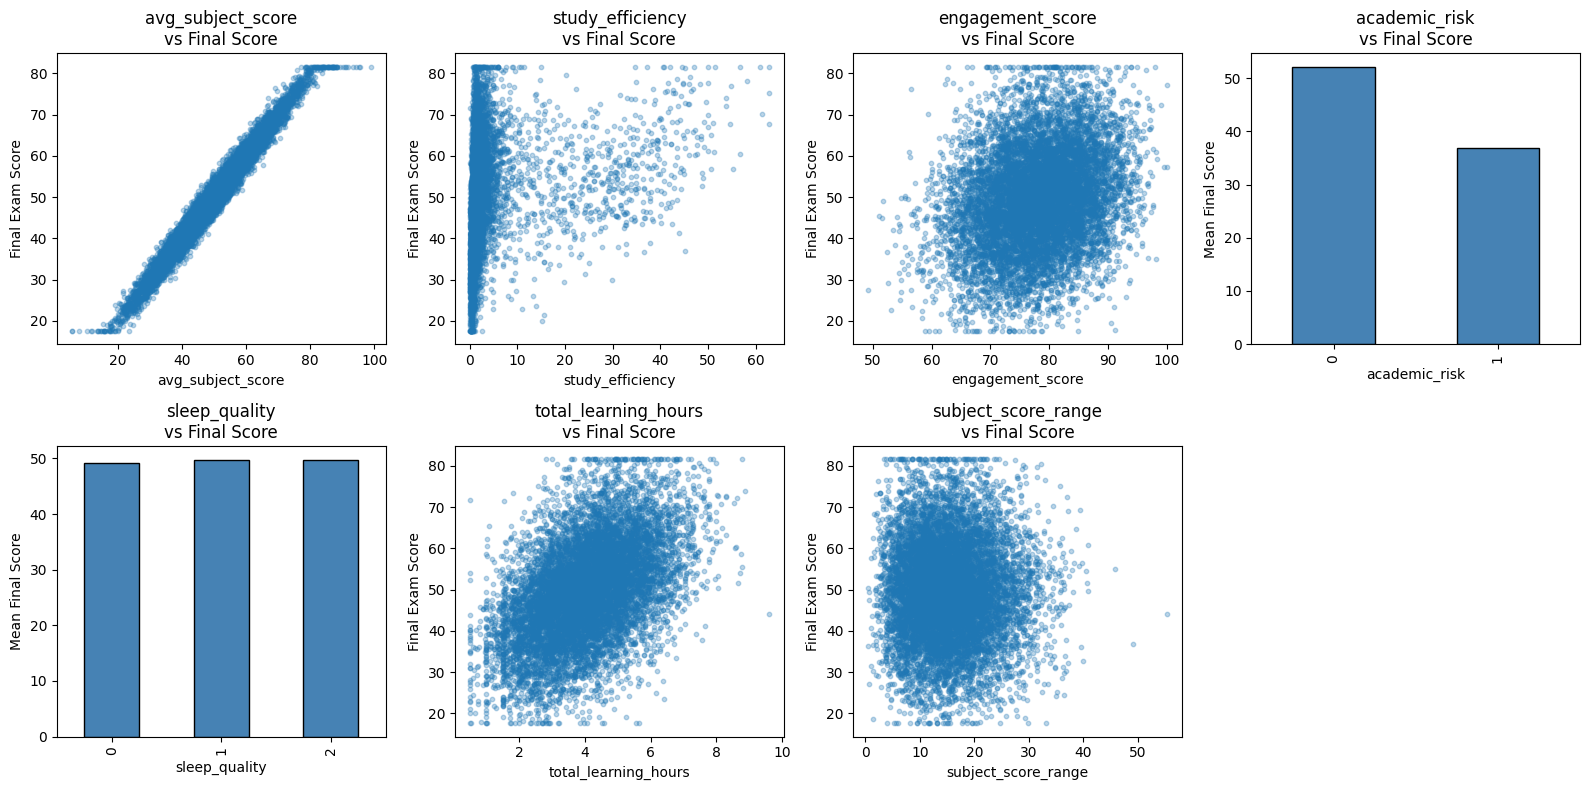

In [19]:
# Visualize new features
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feature in enumerate(new_features):
    if feature in ['academic_risk', 'sleep_quality']:
        # Categorical - bar plot
        df_processed.groupby(feature)['final_exam_score'].mean().plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='black')
        axes[i].set_title(f'{feature}\nvs Final Score')
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('Mean Final Score')
    else:
        # Continuous - scatter plot
        axes[i].scatter(df_processed[feature], df_processed['final_exam_score'], alpha=0.3, s=10)
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('Final Exam Score')
        axes[i].set_title(f'{feature}\nvs Final Score')

# Hide last subplot
axes[7].set_visible(False)

plt.tight_layout()
plt.savefig('../docs/new_features_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## <font color="red">4. Feature Selection & Scaling</font>

### <font color="blue">4.1 Define Feature Sets for Different Tasks</font>

In [20]:
# Define feature sets

# Original numerical features (excluding target variables)
numerical_features = ['age', 'study_hours_per_day', 'attendance_rate', 'sleep_hours',
                      'social_media_hours', 'assignment_completion_rate', 'participation_score',
                      'online_courses_completed']

# Subject scores
subject_features = ['math_score', 'reading_score', 'writing_score', 'science_score']

# Encoded categorical features
encoded_features = ['gender_encoded', 'parental_education_encoded', 'family_income_encoded',
                    'internet_access_encoded', 'tutoring_encoded'] + \
                   [c for c in df_processed.columns if c.startswith('study_environment_')]

# New engineered features
engineered_features = ['avg_subject_score', 'study_efficiency', 'engagement_score',
                        'academic_risk', 'sleep_quality', 'total_learning_hours', 'subject_score_range']

# Historical academic performance
historical_features = ['previous_gpa']

# Target variables
target_regression = 'final_exam_score'
target_binary_class = 'pass_fail_encoded'
target_multi_class = 'grade_category_encoded'

print("Feature Sets Defined:")
print(f"  Numerical features: {len(numerical_features)}")
print(f"  Subject scores: {len(subject_features)}")
print(f"  Encoded features: {len(encoded_features)}")
print(f"  Engineered features: {len(engineered_features)}")
print(f"  Historical features: {len(historical_features)}")

Feature Sets Defined:
  Numerical features: 8
  Subject scores: 4
  Encoded features: 8
  Engineered features: 7
  Historical features: 1


In [21]:
# Create feature sets for different scenarios

# Scenario 1: Predict final exam score WITHOUT subject scores (before exam)
features_without_subjects = numerical_features + encoded_features + engineered_features[:4] + historical_features
print(f"\nScenario 1 - Predict final score WITHOUT subject scores: {len(features_without_subjects)} features")

# Scenario 2: Predict final exam score WITH subject scores (after exam)
features_with_subjects = numerical_features + subject_features + encoded_features + engineered_features + historical_features
print(f"Scenario 2 - Predict final score WITH subject scores: {len(features_with_subjects)} features")

# Scenario 3: Minimal features (most important from EDA)
features_minimal = ['previous_gpa', 'study_hours_per_day', 'attendance_rate', 'assignment_completion_rate']
print(f"Scenario 3 - Minimal features (key predictors): {len(features_minimal)} features")


Scenario 1 - Predict final score WITHOUT subject scores: 21 features
Scenario 2 - Predict final score WITH subject scores: 28 features
Scenario 3 - Minimal features (key predictors): 4 features


### <font color="blue">4.2 Feature Scaling</font>

In [22]:
# Select features for modeling (using Scenario 2 - with subject scores)
selected_features = features_with_subjects.copy()

# Create feature matrix and target vector
X = df_processed[selected_features]
y_regression = df_processed[target_regression]
y_binary = df_processed[target_binary_class]

print(f"Feature matrix shape: {X.shape}")
print(f"Target (regression) shape: {y_regression.shape}")
print(f"Target (binary class) shape: {y_binary.shape}")

Feature matrix shape: (10000, 28)
Target (regression) shape: (10000,)
Target (binary class) shape: (10000,)


In [23]:
# Identify features that need scaling
features_to_scale = numerical_features + subject_features + engineered_features + historical_features
features_to_scale = [f for f in features_to_scale if f in selected_features]

print(f"Features to scale: {len(features_to_scale)}")
print(features_to_scale)

Features to scale: 20
['age', 'study_hours_per_day', 'attendance_rate', 'sleep_hours', 'social_media_hours', 'assignment_completion_rate', 'participation_score', 'online_courses_completed', 'math_score', 'reading_score', 'writing_score', 'science_score', 'avg_subject_score', 'study_efficiency', 'engagement_score', 'academic_risk', 'sleep_quality', 'total_learning_hours', 'subject_score_range', 'previous_gpa']


In [24]:
# Apply Standard Scaling
scaler = StandardScaler()

# Create a copy for scaled data
X_scaled = X.copy()

# Scale the features
X_scaled[features_to_scale] = scaler.fit_transform(X[features_to_scale])

print("\nScaled Features Statistics:")
print(X_scaled[features_to_scale].describe().loc[['mean', 'std']].transpose())


Scaled Features Statistics:
                                    mean      std
age                         1.296030e-15  1.00005
study_hours_per_day        -1.051603e-16  1.00005
attendance_rate             2.032152e-16  1.00005
sleep_hours                -4.327205e-16  1.00005
social_media_hours         -4.050094e-17  1.00005
assignment_completion_rate  1.639577e-16  1.00005
participation_score        -1.031708e-15  1.00005
online_courses_completed   -9.094947e-17  1.00005
math_score                  3.439027e-16  1.00005
reading_score              -8.242296e-17  1.00005
writing_score              -4.177991e-16  1.00005
science_score               2.557954e-16  1.00005
avg_subject_score           3.268497e-17  1.00005
study_efficiency           -1.563194e-17  1.00005
engagement_score           -4.902745e-16  1.00005
academic_risk              -1.847411e-17  1.00005
sleep_quality               1.193712e-16  1.00005
total_learning_hours       -4.618528e-16  1.00005
subject_score_range  

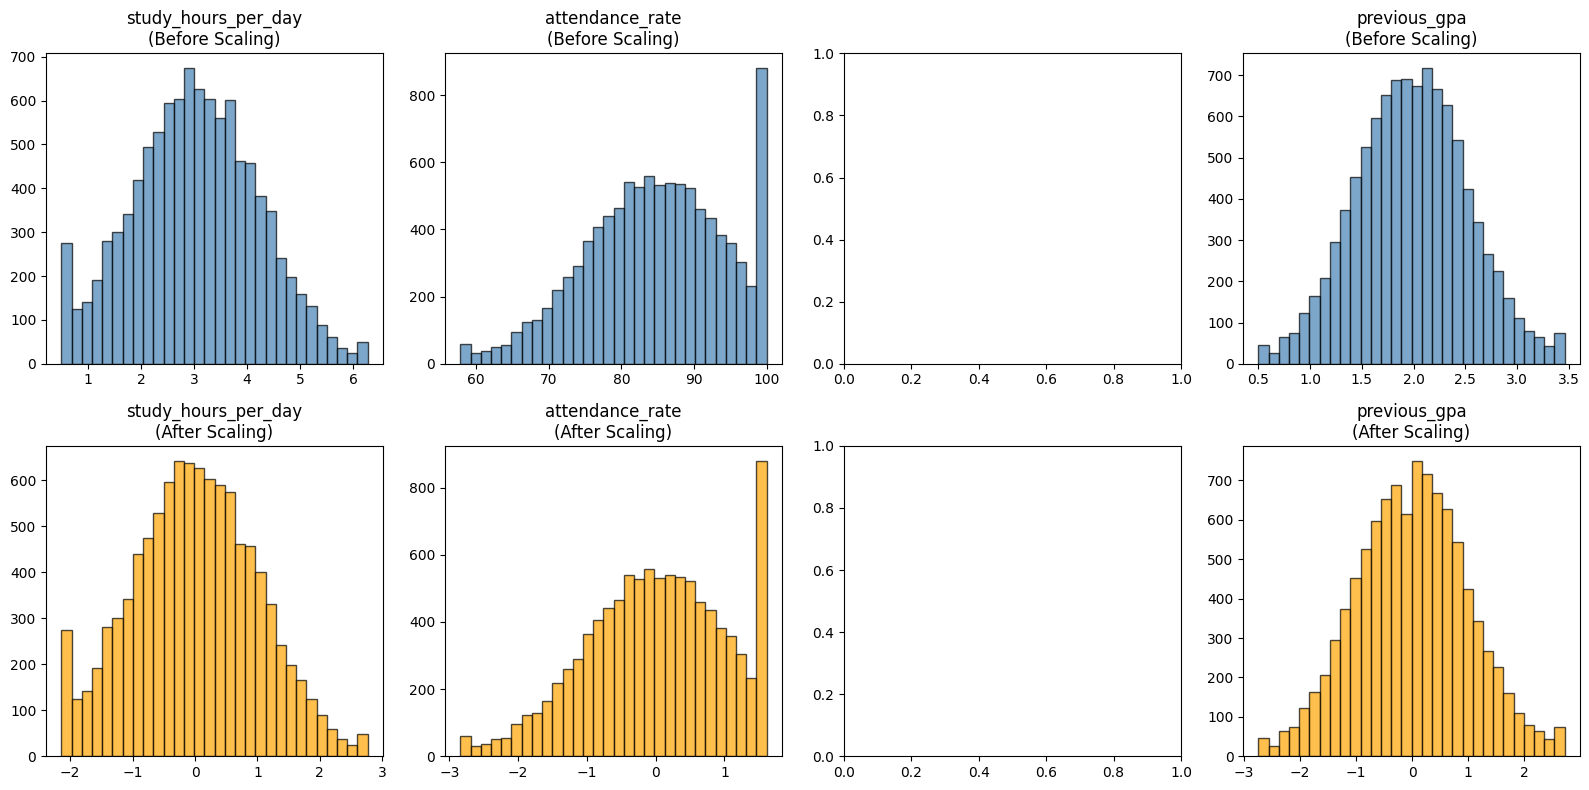

In [25]:
# Visualize scaling effect
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

sample_features = ['study_hours_per_day', 'attendance_rate', 'final_exam_score', 'previous_gpa']

for i, feature in enumerate(sample_features[:4]):
    # Before scaling
    if feature in X.columns:
        axes[0, i].hist(X[feature], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
        axes[0, i].set_title(f'{feature}\n(Before Scaling)')
    
    # After scaling
    if feature in X_scaled.columns:
        axes[1, i].hist(X_scaled[feature], bins=30, color='orange', edgecolor='black', alpha=0.7)
        axes[1, i].set_title(f'{feature}\n(After Scaling)')

plt.tight_layout()
plt.savefig('../docs/feature_scaling_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## <font color="red">5. Train-Test Split</font>

In [26]:
# Split data for regression task
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_scaled, y_regression, test_size=0.2, random_state=42
)

print("Regression Task - Train/Test Split:")
print(f"  Training set: {X_train_reg.shape[0]} samples")
print(f"  Test set: {X_test_reg.shape[0]} samples")
print(f"  Features: {X_train_reg.shape[1]}")

Regression Task - Train/Test Split:
  Training set: 8000 samples
  Test set: 2000 samples
  Features: 28


In [27]:
# Split data for binary classification task
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_scaled, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

print("\nClassification Task - Train/Test Split:")
print(f"  Training set: {X_train_cls.shape[0]} samples")
print(f"  Test set: {X_test_cls.shape[0]} samples")
print(f"  Features: {X_train_cls.shape[1]}")

# Check class distribution
print(f"\nClass distribution in training set:")
print(f"  Pass (1): {y_train_cls.sum()} ({y_train_cls.mean()*100:.1f}%)")
print(f"  Fail (0): {len(y_train_cls) - y_train_cls.sum()} ({(1-y_train_cls.mean())*100:.1f}%)")


Classification Task - Train/Test Split:
  Training set: 8000 samples
  Test set: 2000 samples
  Features: 28

Class distribution in training set:
  Pass (1): 3886 (48.6%)
  Fail (0): 4114 (51.4%)


## <font color="red">6. Save Processed Data</font>

In [28]:
# Save processed dataframe
df_processed.to_csv('../dataset/student_data_processed.csv', index=False)
print(f"Processed dataset saved to: ../dataset/student_data_processed.csv")
print(f"Shape: {df_processed.shape}")

Processed dataset saved to: ../dataset/student_data_processed.csv
Shape: (10000, 39)


In [29]:
# Save train/test splits for modeling
import joblib

# Save regression data
joblib.dump((X_train_reg, X_test_reg, y_train_reg, y_test_reg), '../dataset/train_test_regression.pkl')
print("Regression train/test data saved")

# Save classification data
joblib.dump((X_train_cls, X_test_cls, y_train_cls, y_test_cls), '../dataset/train_test_classification.pkl')
print("Classification train/test data saved")

# Save scaler and feature lists
preprocessing_objects = {
    'scaler': scaler,
    'label_encoders': label_encoders,
    'selected_features': selected_features,
    'features_to_scale': features_to_scale,
    'education_order': education_order,
    'income_order': income_order,
    'grade_order': grade_order
}
joblib.dump(preprocessing_objects, '../dataset/preprocessing_objects.pkl')
print("Preprocessing objects saved")

Regression train/test data saved
Classification train/test data saved
Preprocessing objects saved


In [30]:
# Verify saved files
import os

files = ['student_data_processed.csv', 'train_test_regression.pkl', 
         'train_test_classification.pkl', 'preprocessing_objects.pkl']

print("\nSaved Files:")
print("="*50)
for f in files:
    path = f'../dataset/{f}'
    if os.path.exists(path):
        size = os.path.getsize(path)
        print(f"  {f}: {size/1024:.1f} KB")


Saved Files:
  student_data_processed.csv: 1888.4 KB
  train_test_regression.pkl: 2583.4 KB
  train_test_classification.pkl: 2583.4 KB
  preprocessing_objects.pkl: 3.5 KB


## <font color="red">7. Summary</font>

In [31]:
print("="*60)
print("DATA PREPROCESSING & FEATURE ENGINEERING SUMMARY")
print("="*60)

print("\n1. DATA PREPROCESSING:")
print("   - Outliers capped using IQR method")
print(f"   - {len(binary_cols)} binary columns -> Label Encoding")
print(f"   - {len(ordinal_cols)} ordinal columns -> Ordinal Encoding")
print(f"   - {len(nominal_cols)} nominal columns -> One-Hot Encoding")

print("\n2. FEATURE ENGINEERING:")
print(f"   - Created {len(new_features)} new features:")
for f in new_features:
    corr = df_processed[f].corr(df_processed['final_exam_score'])
    print(f"     * {f}: r = {corr:+.3f}")

print("\n3. FEATURE SCALING:")
print(f"   - StandardScaler applied to {len(features_to_scale)} features")

print("\n4. DATA SPLIT:")
print(f"   - Training set: {X_train_reg.shape[0]} samples (80%)")
print(f"   - Test set: {X_test_reg.shape[0]} samples (20%)")
print(f"   - Total features: {X_train_reg.shape[1]}")

print("\n5. SAVED FILES:")
print("   - student_data_processed.csv")
print("   - train_test_regression.pkl")
print("   - train_test_classification.pkl")
print("   - preprocessing_objects.pkl")

print("\n" + "="*60)
print("READY FOR MODELING!")
print("="*60)

DATA PREPROCESSING & FEATURE ENGINEERING SUMMARY

1. DATA PREPROCESSING:
   - Outliers capped using IQR method
   - 4 binary columns -> Label Encoding
   - 3 ordinal columns -> Ordinal Encoding
   - 1 nominal columns -> One-Hot Encoding

2. FEATURE ENGINEERING:
   - Created 7 new features:
     * avg_subject_score: r = +0.985
     * study_efficiency: r = +0.224
     * engagement_score: r = +0.253
     * academic_risk: r = -0.461
     * sleep_quality: r = +0.013
     * total_learning_hours: r = +0.486
     * subject_score_range: r = -0.016

3. FEATURE SCALING:
   - StandardScaler applied to 20 features

4. DATA SPLIT:
   - Training set: 8000 samples (80%)
   - Test set: 2000 samples (20%)
   - Total features: 28

5. SAVED FILES:
   - student_data_processed.csv
   - train_test_regression.pkl
   - train_test_classification.pkl
   - preprocessing_objects.pkl

READY FOR MODELING!
